Import current pipeline timing CSV

In [1]:
LOG_DIR = '../../experiments/current/'


In [2]:
# Parameters
LOG_DIR = "../../experiments/current/"


In [3]:
import pandas as pd
import os


long_term_memory = False

# Chargement du fichier CSV
df = pd.read_csv(LOG_DIR + 'pipeline_timing.csv')

colonnes_not_nan = df.columns[df.isna().all()==False]
df.drop(columns=['agent_id'], inplace=True)

if long_term_memory == False:
    df.drop(columns=['T_ltm_start', 'T_ltm_end'], inplace=True)


print("Na Columns: ")
print(df.columns[df.isna().all()])


print(df.isna().sum())


def _stat_path(title, ext="csv"):
    name = "".join(c if c.isalnum() or c in "-_" else "_" for c in title)
    img_dir = os.path.join(LOG_DIR, "images/pipeline")
    os.makedirs(img_dir, exist_ok=True)
    return os.path.join(img_dir, f"{name}.{ext}")


Na Columns: 
Index(['T_parse'], dtype='str')
sim_time                  0
T0                        0
T_parse                8768
T_flag                    0
T_otp_start             310
T_transit_sem          1467
T_transit_end          1467
T_osmnx_sem            6349
T_osmnx_end             319
T_otp_end               319
T_llm_start             333
T_llm_sent              334
T_llm_result            334
T_extract_end           710
T_enqueue                16
T_fin                     0
P4_4_ms                8767
P5_1_ms                8767
P5_3_ms                8767
P5_4_ms                8767
P5_5_ms                8767
P5_llm_provider        8767
P5_llm_retries            0
P5_tokens_in              0
P5_tokens_out             0
plan_selected_index      10
selection_method         10
dtype: int64


Extract Date columns in df_delay

In [4]:
df_delay = df.drop(columns=['P4_4_ms', 'P5_1_ms', 'P5_3_ms', 'P5_4_ms',
       'P5_5_ms', 'P5_llm_provider', 'P5_llm_retries', 'P5_tokens_in',
       'P5_tokens_out'])

df_delay

,sim_time,T0,T_parse,T_flag,T_otp_start,T_transit_sem,T_transit_end,T_osmnx_sem,T_osmnx_end,T_otp_end,T_llm_start,T_llm_sent,T_llm_result,T_extract_end,T_enqueue,T_fin,plan_selected_index,selection_method
0,1773705600,1.779465e+09,NaN,1.779465e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.779465e+09,0.0,Pas de déplacement (même localisation)
1,1773680136,1.779465e+09,NaN,1.779465e+09,1.779465e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.779465e+09,NaN,NaN
2,1773675366,1.779465e+09,NaN,1.779465e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.779465e+09,0.0,Pas de déplacement (même localisation)
3,1773680378,1.779465e+09,NaN,1.779465e+09,1.779465e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.779465e+09,NaN,NaN
4,1773681306,1.779465e+09,NaN,1.779465e+09,1.779465e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.779465e+09,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8763,1774428389,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,4.0,LLM
8764,1774430855,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,0.0,LLM
8765,1774515782,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.0,LLM
8766,1774430849,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,NaN,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,1.779479e+09,0.0,LLM


Compute delays

In [5]:
df_delay["parse"]        = df_delay["T_parse"]       - df_delay["T0"]
df_delay["flag"]         = df_delay["T_flag"]        - df_delay["T_parse"]
df_delay["gap_otp"]      = df_delay["T_otp_start"]   - df_delay["T_flag"]
df_delay["transit_sem"]  = df_delay["T_transit_sem"] - df_delay["T_otp_start"]  # 3A queue
df_delay["transit_req"]  = df_delay["T_transit_end"] - df_delay["T_transit_sem"] # 3A HTTP
df_delay["transit"]      = df_delay["T_transit_end"] - df_delay["T_otp_start"]   # 3A total
df_delay["osmnx_sem"]    = df_delay["T_osmnx_sem"]   - df_delay["T_otp_start"]  # 3B queue (HTTP mode)
df_delay["osmnx_req"]    = df_delay["T_osmnx_end"]   - df_delay["T_osmnx_sem"]  # 3B processing (HTTP mode)
df_delay["osmnx"]        = df_delay["T_osmnx_end"]   - df_delay["T_otp_start"]  # 3B total
df_delay["otp"]          = df_delay["T_otp_end"]     - df_delay["T_otp_start"]  # 3 total = max(3A, 3B)
df_delay["gap_llm"]      = df_delay["T_llm_start"]   - df_delay["T_otp_end"]    # 3→5 transition
df_delay["llm_post"]     = df_delay["T_llm_sent"]    - df_delay["T_llm_start"]
df_delay["llm_wait"]     = df_delay["T_llm_result"]  - df_delay["T_llm_sent"]
df_delay["extract"]      = df_delay["T_extract_end"] - df_delay["T_llm_result"]
df_delay["enqueue"]      = df_delay["T_enqueue"]     - df_delay["T_extract_end"]
df_delay["ws"]           = df_delay["T_fin"]         - df_delay["T_enqueue"]
df_delay["total"]        = df_delay["T_fin"]         - df_delay["T0"]

if long_term_memory:
    df_delay["ltm"] = df_delay["T_ltm_end"] - df_delay["T_ltm_start"]

timestamp_cols = ["T_parse", "T_flag", "T_otp_start",
                  "T_transit_sem", "T_transit_end", "T_osmnx_sem", "T_osmnx_end", "T_otp_end",
                  "T_llm_start", "T_llm_sent", "T_llm_result", "T_extract_end", "T_enqueue"]
if long_term_memory:
    timestamp_cols += ["T_ltm_start", "T_ltm_end"]
df_delay = df_delay.drop(columns=[c for c in timestamp_cols if c in df_delay.columns])
df_delay

,sim_time,T0,T_fin,plan_selected_index,selection_method,parse,flag,gap_otp,transit_sem,transit_req,...,osmnx_req,osmnx,otp,gap_llm,llm_post,llm_wait,extract,enqueue,ws,total
0,1773705600,1.779465e+09,1.779465e+09,0.0,Pas de déplacement (même localisation),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032488
1,1773680136,1.779465e+09,1.779465e+09,NaN,NaN,NaN,NaN,0.000013,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028779
2,1773675366,1.779465e+09,1.779465e+09,0.0,Pas de déplacement (même localisation),NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027850
3,1773680378,1.779465e+09,1.779465e+09,NaN,NaN,NaN,NaN,0.000010,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022011
4,1773681306,1.779465e+09,1.779465e+09,NaN,NaN,NaN,NaN,0.000006,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8763,1774428389,1.779479e+09,1.779479e+09,4.0,LLM,NaN,NaN,0.000031,0.043069,0.074626,...,NaN,0.043720,0.144147,0.001140,0.05092,2.066414,0.001706,0.002306,0.002247,2.268910
8764,1774430855,1.779479e+09,1.779479e+09,0.0,LLM,NaN,NaN,0.000031,0.000386,0.607892,...,NaN,0.000986,0.608461,0.000525,0.01030,2.694429,0.002349,0.004129,0.001232,3.321455
8765,1774515782,1.779479e+09,1.779479e+09,1.0,LLM,NaN,NaN,0.000025,0.043234,0.308767,...,NaN,0.043500,0.363025,0.000819,0.01703,2.749089,0.001512,0.004909,0.002817,3.139226
8766,1774430849,1.779479e+09,1.779479e+09,0.0,LLM,NaN,NaN,0.000025,0.000307,0.087181,...,NaN,0.000708,0.093174,0.000830,0.01668,11.216380,0.003228,0.002697,0.001032,11.334046


In [6]:
delay_cols_ordered = [
    "parse",        # 1
    "flag",         # 2
    "gap_otp",      # 2→3
    "otp",          # 3 total
    "transit",      # 3A total
    "transit_sem",  # 3A-queue
    "transit_req",  # 3A-calc
    "osmnx",        # 3B total
    "osmnx_sem",    # 3B-queue (HTTP mode)
    "osmnx_req",    # 3B-calc (HTTP mode)
    "gap_llm",      # 3→5
    "llm_post",     # 5
    "llm_wait",     # 6
    "extract",      # 7
    "enqueue",      # 8
    "ws",           # 9
    "total",
]
if long_term_memory:
    delay_cols_ordered.insert(delay_cols_ordered.index("llm_post"), "ltm")

delay_cols_ordered = [c for c in delay_cols_ordered if c in df_delay.columns]

descriptions = {
    "parse":       "1     — Parsing JSON + validation Pydantic de la requête GAMA",
    "flag":        "2     — Filtrage des agents éligibles (scan de toute la population)",
    "gap_otp":     "2→3   — Délai asyncio entre lancement des tâches et démarrage OTP",
    "otp":         "3     — OTP + OSMnx gather total : durée = max(3A, 3B)",
    "transit":     "3A    — OTP transit total (queue + requête HTTP GraphQL)",
    "transit_sem": "3A-q  — Attente sémaphore OTP (queue, avant accès HTTP)",
    "transit_req": "3A-c  — Requête HTTP GraphQL OTP (calcul itinéraire transit)",
    "osmnx":       "3B    — OSMnx pied/vélo/voiture total (parallèle avec 3A)",
    "osmnx_sem":   "3B-q  — Attente sémaphore OSMnx (HTTP mode uniquement)",
    "osmnx_req":   "3B-c  — Calcul OSMnx après sémaphore (HTTP ou process pool)",
    "gap_llm":     "3→5   — Sélection candidats + construction payload LLM (non instrumenté)",
    "ltm":         "4     — Requête ChromaDB mémoire long terme (si LTM activée)",
    "llm_post":    "5     — HTTP POST création de la tâche dans le gateway LLM",
    "llm_wait":    "6     — Attente résultat LLM : long-poll Pub/Sub (micro-batch + worker + inférence)",
    "extract":     "7     — Extraction chosen_index + remapping vers le plan original (post-shuffle)",
    "enqueue":     "8     — Construction PersonMove + MoveLogger I/O + enqueue",
    "ws":          "9     — Attente envoi WebSocket vers GAMA (publish_loop)",
    "total":       "TOTAL — Durée totale pipeline T0 → T_fin",
}

delay_mean_df = df_delay[delay_cols_ordered].describe().loc[["mean", "std", "min", "max"]].T
delay_mean_df["Description"] = delay_mean_df.index.map(descriptions)
delay_mean_df.to_csv(_stat_path("pipeline_delay_summary"))
print(_stat_path("pipeline_delay_summary"))
delay_mean_df.style.format("{:.4f}", subset=["mean", "std", "min", "max"])


../../experiments/current/images/pipeline/pipeline_delay_summary.csv


,mean,std,min,max,Description
parse,nan,nan,nan,nan,1 — Parsing JSON + validation Pydantic de la requête GAMA
flag,nan,nan,nan,nan,2 — Filtrage des agents éligibles (scan de toute la population)
gap_otp,0.0001,0.0005,0.0000,0.0426,2→3 — Délai asyncio entre lancement des tâches et démarrage OTP
otp,2.4764,4.7417,0.0002,31.5795,"3 — OTP + OSMnx gather total : durée = max(3A, 3B)"
transit,1.1492,4.1858,0.0054,31.5192,3A — OTP transit total (queue + requête HTTP GraphQL)
transit_sem,0.8210,4.0429,0.0001,30.3381,"3A-q — Attente sémaphore OTP (queue, avant accès HTTP)"
transit_req,0.3282,0.4899,0.0051,9.3636,3A-c — Requête HTTP GraphQL OTP (calcul itinéraire transit)
osmnx,1.5337,3.0440,0.0001,18.2122,3B — OSMnx pied/vélo/voiture total (parallèle avec 3A)
osmnx_sem,3.5196,3.4680,0.0002,16.6534,3B-q — Attente sémaphore OSMnx (HTTP mode uniquement)
osmnx_req,1.8029,0.5532,0.4597,7.3983,3B-c — Calcul OSMnx après sémaphore (HTTP ou process pool)


Véfification que l'on a toutes les valeurs

In [7]:
# otp = total gather (transit+osmnx parallèles), transit/osmnx sont des sous-composantes
# gap_llm ferme le trou entre OTP et LLM
segment_cols = ["parse", "flag", "gap_otp", "otp", "gap_llm", "llm_post", "llm_wait", "extract", "enqueue", "ws"]
if long_term_memory:
    segment_cols.insert(segment_cols.index("llm_post"), "ltm")
segment_cols = [c for c in segment_cols if c in df_delay.columns]

df_llm = df_delay[df_delay["selection_method"] == "LLM"].copy()
df_llm["sum_segments"] = df_llm[segment_cols].sum(axis=1)
df_llm["diff"] = df_llm["total"] - df_llm["sum_segments"]

print(f"Lignes vérifiées (selection_method=LLM) : {len(df_llm)}")
print(f"Diff max  : {df_llm['diff'].abs().max():.4f} s")
print(f"Diff mean : {df_llm['diff'].abs().mean():.4f} s")
print()
df_llm[["total", "sum_segments", "diff"]].describe().style.format("{:.4f}")

Lignes vérifiées (selection_method=LLM) : 8057
Diff max  : 0.0000 s
Diff mean : 0.0000 s



,total,sum_segments,diff
count,8057.0000,8057.0000,8057.0000
mean,270.3484,270.3484,0.0000
std,372.0902,372.0902,0.0000
min,0.4641,0.4641,0.0000
25%,6.5882,6.5882,0.0000
50%,72.1987,72.1987,0.0000
75%,420.8516,420.8516,0.0000
max,2203.2769,2203.2769,0.0000


---
## Analyse temporelle — Débit, ratio et états des agents

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- moves.csv ---
moves_path = os.path.join(LOG_DIR, "moves.csv")
df_moves = pd.read_csv(moves_path) if os.path.exists(moves_path) else pd.DataFrame()
has_calc_time    = "Heure de calcul" in df_moves.columns
has_sim_time_col = "Temps simulé" in df_moves.columns
print(f"moves.csv : {len(df_moves)} lignes | Heure de calcul={has_calc_time} | Temps simulé={has_sim_time_col}")

# --- gama_arrivals.csv (retard réel à l'arrivée, calculé par GAMA) ---
arrivals_path = os.path.join(LOG_DIR, "gama_results", "gama_arrivals.csv")
df_arrivals = pd.read_csv(arrivals_path) if os.path.exists(arrivals_path) else pd.DataFrame()
print(f"gama_arrivals.csv : {len(df_arrivals)} lignes")

# --- agent_states.csv ---
states_path = os.path.join(LOG_DIR, "gama_results", "agent_states.csv")
df_states = pd.read_csv(states_path) if os.path.exists(states_path) else pd.DataFrame()
print(f"agent_states.csv : {len(df_states)} lignes | colonnes={list(df_states.columns) if not df_states.empty else '—'}")

moves.csv : 9791 lignes | Heure de calcul=True | Temps simulé=True
gama_arrivals.csv : 9155 lignes
agent_states.csv : 884 lignes | colonnes=['step', 'sim_timestamp', 'sim_time', 'inactive', 'ready', 'active', 'total']


In [9]:

df_arrivals["delay_min"] = (df_arrivals["delay_s"] / 60).clip(lower=0).astype(int)
df_arrivals


,move_id,person_id,arrive_at,expected_arrive_at,delay_s,delay_min
0,313f8881-ea0d-48d0-9a85-0951e13913b0,940630,1773640864,1773640867,-3,0
1,c70c5e96-66f2-4b1f-baf5-86abcbda7640,992607,1773640974,1773640977,-3,0
2,9b69a8ab-cf17-45d4-889d-81490f8cc060,1001285,1773641014,1773641015,-1,0
3,ec7dd4d0-54fd-4e10-af42-19916819ba9a,1200749,1773641535,1773641536,-1,0
4,18f75c99-f996-4bf2-b571-181e960ace71,480978,1773641751,1773641752,-1,0
...,...,...,...,...,...,...
9150,cb095781-d1b8-4861-8904-47547ce9526b,732951,1774433284,1774434041,-757,0
9151,1a7fecac-f132-411b-aadb-ca4e4c1144bb,1302332,1774433304,1774429614,3690,61
9152,d646b1cc-39e5-4108-9214-4ce6da6e29a8,762373,1774433359,1774433360,-1,0
9153,ad6384fc-4b8a-4a93-8b65-0d7aa82d6e7a,1430769,1774433369,1774434003,-634,0


### 1. Débit par minute (temps réel) et retard de planification

Barres : nombre de trajets calculés par minute réelle (source : `T_fin` de pipeline_timing.csv).  
Axe secondaire : retard de planification moyen par minute (source : `Heure de calcul` + `Retard planification (s)` de moves.csv si disponibles, sinon durée pipeline totale comme proxy).

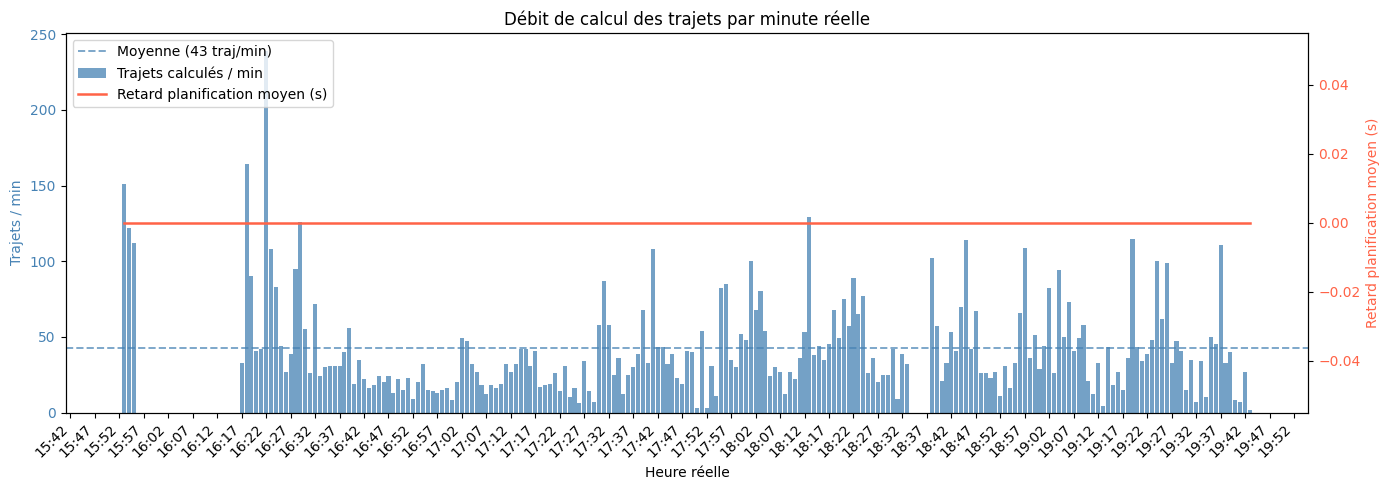

In [10]:
# --- Binning par minute réelle (T_fin depuis pipeline_timing) ---
df_rt = df_delay[["T_fin", "sim_time", "total"]].copy()
df_rt["real_dt"] = pd.to_datetime(df_rt["T_fin"], unit="s", utc=True)
df_rt["real_min"] = df_rt["real_dt"].dt.floor("min")

per_min = (
    df_rt.groupby("real_min")
    .agg(trips=("T_fin", "count"), avg_total=("total", "mean"))
    .reset_index()
    .sort_values("real_min")
)

# Retard de planification : moves.csv (Heure de calcul) si disponible, sinon total pipeline
if has_calc_time and "Retard planification (s)" in df_moves.columns:
    _m = df_moves.copy()
    _m["real_dt"] = pd.to_datetime(_m["Heure de calcul"], utc=True)
    _m["real_min"] = _m["real_dt"].dt.floor("min")
    _delay = _m.groupby("real_min")["Retard planification (s)"].mean().rename("avg_delay")
    per_min = per_min.join(_delay, on="real_min")
    delay_label_min = "Retard planification moyen (s)"
else:
    per_min["avg_delay"] = per_min["avg_total"]
    delay_label_min = "Durée pipeline moyenne (s) [proxy]"

mean_trips_min = per_min["trips"].mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

bar_width = pd.Timedelta(seconds=50)
ax1.bar(per_min["real_min"], per_min["trips"], width=bar_width,
        color="steelblue", alpha=0.75, label="Trajets calculés / min")
ax1.axhline(mean_trips_min, linestyle="--", color="steelblue", linewidth=1.4, alpha=0.7,
            label=f"Moyenne ({mean_trips_min:.0f} traj/min)")
ax2.plot(per_min["real_min"], per_min["avg_delay"],
         color="tomato", linewidth=1.8, label=delay_label_min)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax1.set_xlabel("Heure réelle")
ax1.set_ylabel("Trajets / min", color="steelblue")
ax2.set_ylabel(delay_label_min, color="tomato")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="tomato")
ax1.set_title("Débit de calcul des trajets par minute réelle")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
fig.tight_layout()
plt.savefig(_stat_path("throughput_per_real_minute", "png"), dpi=150)
plt.show()

### 2. Débit par heure simulée et retard de planification

Barres : nombre de trajets calculés par heure simulée (source : `sim_time` de pipeline_timing.csv).  
Axe secondaire : retard de planification moyen par heure simulée (source : `Temps simulé` + `Retard planification (s)` de moves.csv si disponibles, sinon durée pipeline totale comme proxy).  
L'axe X est exprimé en heures simulées relatives au début de la simulation.

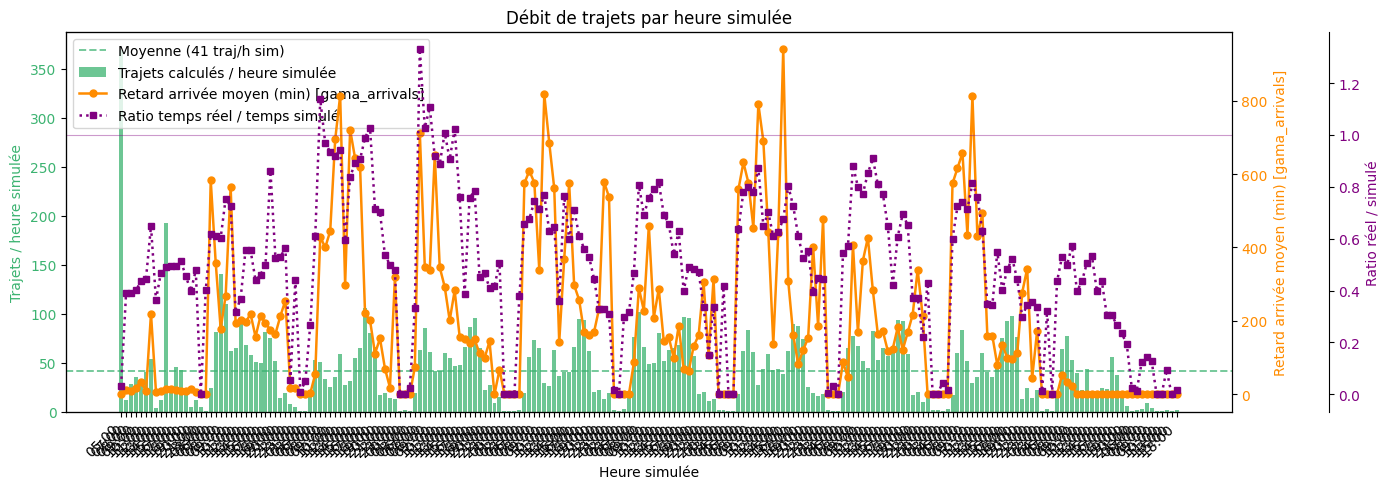

In [11]:
# --- Binning par heure simulée ---
sim_start = df_delay["sim_time"].min()

df_sh = df_delay[["sim_time", "total"]].copy()
df_sh["sim_hour"] = ((df_sh["sim_time"] - sim_start) / 3600).astype(int)

per_sim_hour = (
    df_sh.groupby("sim_hour")
    .agg(trips=("total", "count"), avg_total=("total", "mean"))
    .reset_index()
)

# Ratio temps réel / temps simulé : pour chaque heure simulée,
# on mesure la fenêtre réelle [min(T0), max(T_fin)] de toutes les tâches de cette heure
_real_span = df_delay[["T0", "T_fin", "sim_time"]].copy()
_real_span["sim_hour"] = ((_real_span["sim_time"] - sim_start) / 3600).astype(int)
_real_span = _real_span.groupby("sim_hour").agg(
    T0_min=("T0", "min"),
    T_fin_max=("T_fin", "max"),
).reset_index()
_real_span["real_elapsed"] = _real_span["T_fin_max"] - _real_span["T0_min"]
_real_span["ratio_real_sim"] = _real_span["real_elapsed"] / 3600.0
per_sim_hour = per_sim_hour.merge(_real_span[["sim_hour", "ratio_real_sim"]], on="sim_hour", how="left")

# Retard réel à l'arrivée : gama_arrivals.csv (delay_s = arrive_at - expected_arrive_at)
# Priorité : gama_arrivals > Temps simulé dans moves.csv > proxy total pipeline
if not df_arrivals.empty and "delay_s" in df_arrivals.columns:
    _arr = df_arrivals.copy()
    _arr["sim_hour"] = ((_arr["expected_arrive_at"] - sim_start) / 3600).astype(int)
    _delay_arr = (
        _arr[_arr["delay_s"] > 0]
        .groupby("sim_hour")["delay_s"]
        .mean()
        .rename("avg_delay")
    )
    per_sim_hour = per_sim_hour.join(_delay_arr, on="sim_hour")
    per_sim_hour["avg_delay"] = per_sim_hour["avg_delay"].fillna(0)/60
    delay_label_sh = "Retard arrivée moyen (min) [gama_arrivals]"
elif has_sim_time_col and "Retard planification (s)" in df_moves.columns:
    _ms = df_moves.copy()
    _ms["sim_hour"] = ((_ms["Temps simulé"] - sim_start) / 3600).astype(int)
    _delay_sh = _ms.groupby("sim_hour")["Retard planification (s)"].mean().rename("avg_delay")
    per_sim_hour = per_sim_hour.join(_delay_sh, on="sim_hour")
    per_sim_hour["avg_delay"] = per_sim_hour["avg_delay"].fillna(0)/60
    delay_label_sh = "Retard planification moyen (min) [gama_arrivals]"
else:
    per_sim_hour["avg_delay"] = per_sim_hour["avg_total"]
    delay_label_sh = "Durée pipeline moyenne (s) [proxy]"

mean_trips_sh = per_sim_hour["trips"].mean()

# Labels d'axe X : heure simulée absolue (HH:MM)
sim_hour_labels = [
    pd.Timestamp(sim_start + h * 3600, unit="s").strftime("%H:%M")
    for h in per_sim_hour["sim_hour"]
]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 70))

x = np.arange(len(per_sim_hour))
ax1.bar(x, per_sim_hour["trips"], color="mediumseagreen", alpha=0.75, label="Trajets calculés / heure simulée")
ax1.axhline(mean_trips_sh, linestyle="--", color="mediumseagreen", linewidth=1.4, alpha=0.7,
            label=f"Moyenne ({mean_trips_sh:.0f} traj/h sim)")
ax2.plot(x, per_sim_hour["avg_delay"], color="darkorange",
         linewidth=1.8, marker="o", markersize=5, label=delay_label_sh)
ax3.plot(x, per_sim_hour["ratio_real_sim"], color="purple",
         linewidth=1.8, marker="s", markersize=4, linestyle=":",
         label="Ratio temps réel / temps simulé")
ax3.axhline(1.0, linestyle="-", color="purple", linewidth=0.8, alpha=0.4)

ax1.set_xticks(x)
ax1.set_xticklabels(sim_hour_labels, rotation=45, ha="right")
ax1.set_xlabel("Heure simulée")
ax1.set_ylabel("Trajets / heure simulée", color="mediumseagreen")
ax2.set_ylabel(delay_label_sh, color="darkorange")
ax3.set_ylabel("Ratio réel / simulé", color="purple")
ax1.tick_params(axis="y", labelcolor="mediumseagreen")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax3.tick_params(axis="y", labelcolor="purple")
ax1.set_title("Débit de trajets par heure simulée")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax1.legend(h1 + h2 + h3, l1 + l2 + l3, loc="upper left")
fig.tight_layout()
plt.savefig(_stat_path("throughput_per_sim_hour", "png"), dpi=150)
plt.show()

In [12]:
per_sim_hour

,sim_hour,trips,avg_total,ratio_real_sim,avg_delay
0,0,369,70.014711,0.034173,0.000000
1,2,12,1229.186768,0.390195,10.703704
2,3,28,1239.503088,0.392253,9.792857
3,4,35,1243.322795,0.401132,18.096914
4,5,26,1257.611107,0.436495,34.216667
...,...,...,...,...,...
208,245,1,2.653260,0.000737,0.000000
209,246,1,0.800054,0.000222,0.000000
210,248,2,4.351899,0.094379,0.000000
211,250,1,3.575020,0.000993,0.000000


### 3. Évolution des états des agents (agent_states.csv)

Graphique en aires empilées : inactif / prêt / actif sur toute la durée de la simulation.

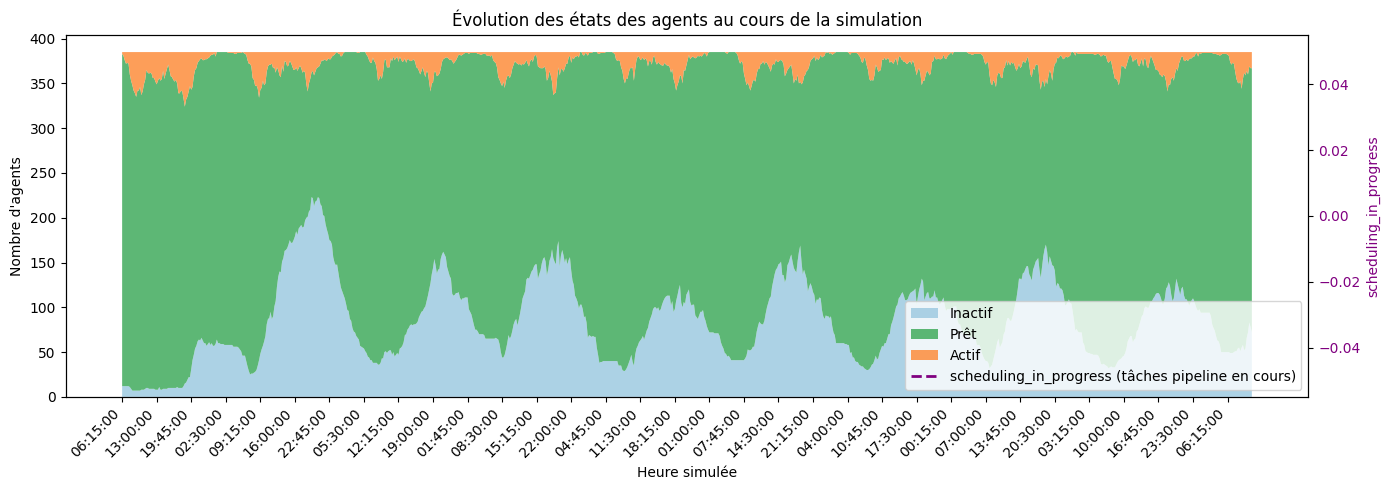

                        count        mean        std    min    25%    50%     75%    max
inactive                884.0   85.561086  45.261561    7.0   50.0   80.0  113.25  223.0
ready                   884.0  285.669683  46.815238  139.0  257.0  294.0  324.00  371.0
active                  884.0   13.769231  12.278429    0.0    3.0   10.5   21.00   61.0
scheduling_in_progress    8.0    0.000000   0.000000    0.0    0.0    0.0    0.00    0.0
total                   884.0  385.000000   0.000000  385.0  385.0  385.0  385.00  385.0


In [13]:
if df_states.empty:
    print("agent_states.csv introuvable — section ignorée")
else:
    # --- Calcul scheduling_in_progress par sync ---
    # T_flag est reconstruit : T0 + parse + flag (tous disponibles dans df_delay)
    # scheduling_in_progress = True sur l'intervalle [T_flag_abs, T_fin] pour chaque tâche
    _tasks = df_delay[["T0", "T_fin", "parse", "flag", "sim_time"]].copy()
    _tasks["T_flag_abs"] = _tasks["T0"] + _tasks["parse"] + _tasks["flag"]
    _tf = _tasks[["T_flag_abs", "T_fin"]].dropna()

    # Temps réel (wall clock) de chaque sync = T0 minimal observé pour ce sim_time
    _sync_wall = df_delay.groupby("sim_time")["T0"].min().reset_index()
    _sync_wall.columns = ["sim_timestamp", "T_sync_wall"]

    df_states_ext = df_states.merge(_sync_wall, on="sim_timestamp", how="left")

    def _count_in_progress(t):
        if pd.isna(t):
            return None
        return int(((_tf["T_flag_abs"] <= t) & (_tf["T_fin"] >= t)).sum())

    df_states_ext["scheduling_in_progress"] = df_states_ext["T_sync_wall"].apply(_count_in_progress)

    # --- Graphique ---
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    ax1.stackplot(
        df_states_ext["sim_timestamp"],
        df_states_ext["inactive"],
        df_states_ext["ready"],
        df_states_ext["active"],
        labels=["Inactif", "Prêt", "Actif"],
        colors=["#9ecae1", "#41ab5d", "#fd8d3c"],
        alpha=0.85,
    )

    ax2.plot(
        df_states_ext["sim_timestamp"],
        df_states_ext["scheduling_in_progress"],
        color="purple", linewidth=2, linestyle="--",
        label="scheduling_in_progress (tâches pipeline en cours)",
    )

    tick_step = max(1, len(df_states_ext) // 32)
    tick_pos  = df_states_ext["sim_timestamp"].iloc[::tick_step].values
    tick_lbl  = df_states_ext["sim_time"].iloc[::tick_step].values
    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels(tick_lbl, rotation=45, ha="right")

    ax1.set_xlabel("Heure simulée")
    ax1.set_ylabel("Nombre d'agents")
    ax2.set_ylabel("scheduling_in_progress", color="purple")
    ax2.tick_params(axis="y", labelcolor="purple")
    ax1.set_title("Évolution des états des agents au cours de la simulation")

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="lower right")
    fig.tight_layout()
    
    # ax1.set_xlim(650000, 750000)
    plt.savefig(_stat_path("agent_states_evolution", "png"), dpi=150)
    plt.show()

    print(df_states_ext[["sim_time", "inactive", "ready", "active", "scheduling_in_progress", "total"]]
          .set_index("sim_time").describe().T.to_string())

In [14]:
df_states

,step,sim_timestamp,sim_time,inactive,ready,active,total
0,1,1773638100,06:15:00,12,371,2,385
1,2,1773639000,06:30:00,12,369,4,385
2,3,1773639900,06:45:00,12,364,9,385
3,4,1773640800,07:00:00,12,360,13,385
4,5,1773641700,07:15:00,12,361,12,385
...,...,...,...,...,...,...,...
879,880,1774429200,10:00:00,66,298,21,385
880,881,1774430100,10:15:00,72,288,25,385
881,882,1774431000,10:30:00,83,286,16,385
882,883,1774431900,10:45:00,78,289,18,385
